# Predicting Student Academic Performance with Multivariate Linear Regression

**Mission:** Improving access to quality education for young people in Africa by helping
schools identify students at risk of underperforming *before* final exams, so that support
(tutoring, counselling, family engagement) can be targeted early.

**Use case:** Given a student's academic history and study habits, predict their **final
grade (G3, 0–20)** in the Portuguese secondary-school Mathematics course. A school can run
this prediction mid-year and intervene for students predicted to score below the pass mark.

**Dataset:** [UCI Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance)
(`student-mat.csv`, 395 students, 33 attributes) — demographic, social and school-related
features collected from two Portuguese schools. The target **G3** is continuous, which makes
this a regression problem (not classification).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

df = pd.read_csv("data/student-mat.csv", sep=";")
print(df.shape)
df.head()

(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 1. Exploring the data

First we check the structure of the dataset: column types and missing values.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [3]:
print("Missing values per column:", df.isna().sum().sum())
df.describe().T.round(2)

Missing values per column: 0


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.70,1.28,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.75,1.09,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.52,1.09,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.45,0.70,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.04,0.84,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.33,0.74,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.94,0.90,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.24,1.00,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.11,1.11,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.48,0.89,1.0,1.0,1.0,2.0,5.0


**Interpretation:** The dataset has **no missing values**, so no imputation is needed.
17 of the 33 columns are stored as text (`object`) — these are categorical and must be
converted to numeric form before modelling. The target `G3` ranges from 0 to 20 with a
mean around 10.4, and `absences` is heavily right-skewed (max 75 vs median 4).

## 2. Visualising the data

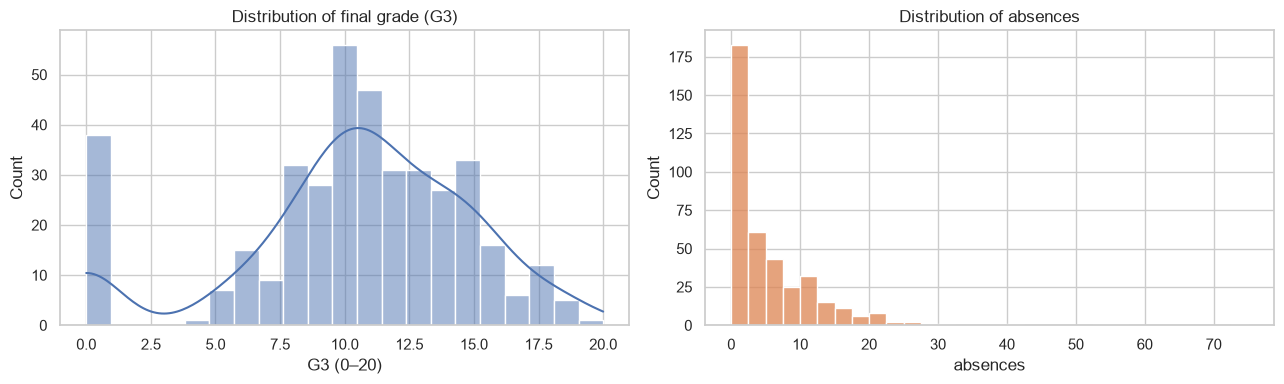

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["G3"], bins=21, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of final grade (G3)")
axes[0].set_xlabel("G3 (0–20)")
sns.histplot(df["absences"], bins=30, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of absences")
plt.tight_layout()
plt.show()

**Interpretation:** G3 is roughly bell-shaped around 10–11, but there is a spike of ~38
students at **exactly 0** — students who dropped out or missed the final exam. These are
genuine outcomes for our mission (they are precisely the at-risk students we want to catch),
so we keep them. Absences are strongly right-skewed: most students miss fewer than 10
classes, while a few miss 40+.

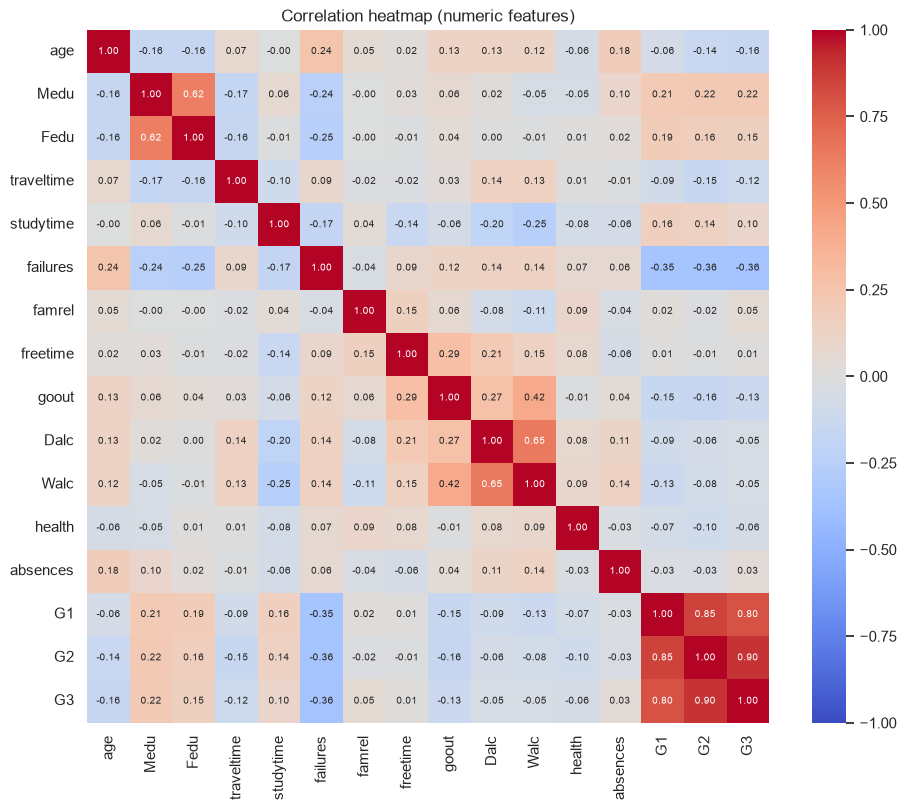

In [5]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(11, 9))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Correlation heatmap (numeric features)")
plt.show()

**Interpretation:** The period grades **G1 (r≈0.80)** and **G2 (r≈0.90)** are by far the
strongest predictors of the final grade — past performance predicts future performance.
**failures (r≈−0.36)** is the strongest negative signal: each past class failure drags the
final grade down. Weaker but meaningful signals: **Medu** (mother's education, r≈0.22),
**age** (r≈−0.16, older students in a year group have often repeated years) and **goout**
(going out with friends, r≈−0.13). `studytime` (r≈0.10) and `absences` (r≈0.03) are weak
on their own but are the *actionable* levers a school can influence, so we examine them
further below.

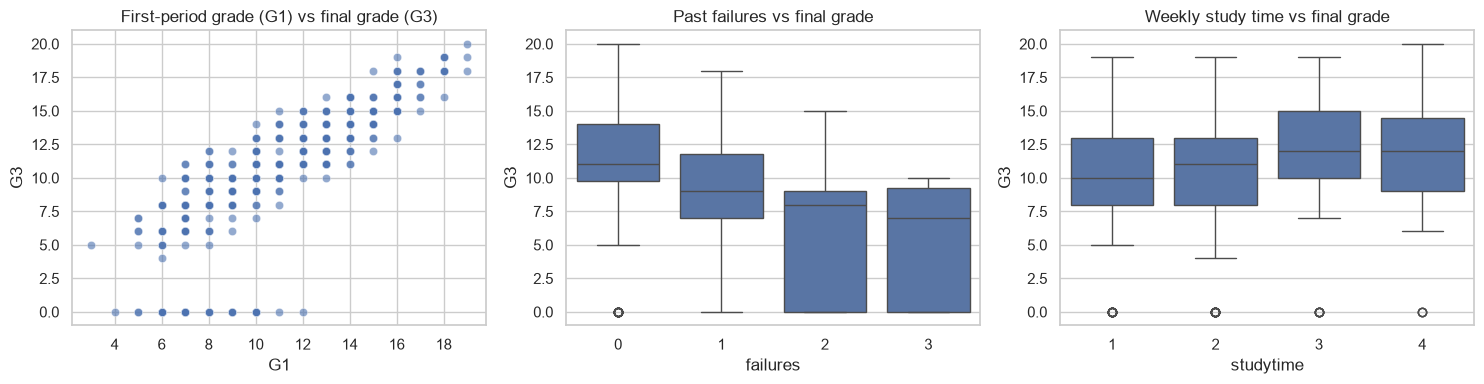

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x="G1", y="G3", ax=axes[0], alpha=0.6)
axes[0].set_title("First-period grade (G1) vs final grade (G3)")
sns.boxplot(data=df, x="failures", y="G3", ax=axes[1])
axes[1].set_title("Past failures vs final grade")
sns.boxplot(data=df, x="studytime", y="G3", ax=axes[2])
axes[2].set_title("Weekly study time vs final grade")
plt.tight_layout()
plt.show()

**Interpretation:** The G1–G3 relationship is clearly **linear**, which justifies a linear
regression model. The failures boxplot shows the median final grade falls from ~11 with zero
failures to ~7 with 3+ failures. Study time shows a mild upward trend — higher study time
shifts the whole distribution up slightly.

## 3. Converting categorical data to numeric

17 columns are text. Two kinds:
- **Binary** columns (`yes/no`, `GP/MS`, `F/M`, …) → mapped to 0/1.
- **Nominal** columns with >2 categories (`Mjob`, `Fjob`, `reason`, `guardian`) → one-hot
  encoded, because they have no natural order and label-encoding them would invent one.

In [7]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print("Categorical columns:", cat_cols)

df_enc = df.copy()
binary_cols = [c for c in cat_cols if df_enc[c].nunique() == 2]
nominal_cols = [c for c in cat_cols if df_enc[c].nunique() > 2]

for c in binary_cols:
    top = sorted(df_enc[c].unique())  # deterministic 0/1 assignment
    df_enc[c] = (df_enc[c] == top[1]).astype(int)

df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True, dtype=int)
print("Shape after encoding:", df_enc.shape)
df_enc.head(3)

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Shape after encoding: (395, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,1,0,0,4,4,2,2,...,0,0,0,0,1,0,0,0,1,0
1,0,0,17,1,0,1,1,1,1,2,...,0,0,1,0,0,0,0,0,0,0
2,0,0,15,1,1,1,1,1,1,2,...,0,0,1,0,0,0,1,0,1,0


## 4. Feature engineering — what do we keep?

With everything numeric we can rank every feature by its correlation with the target.

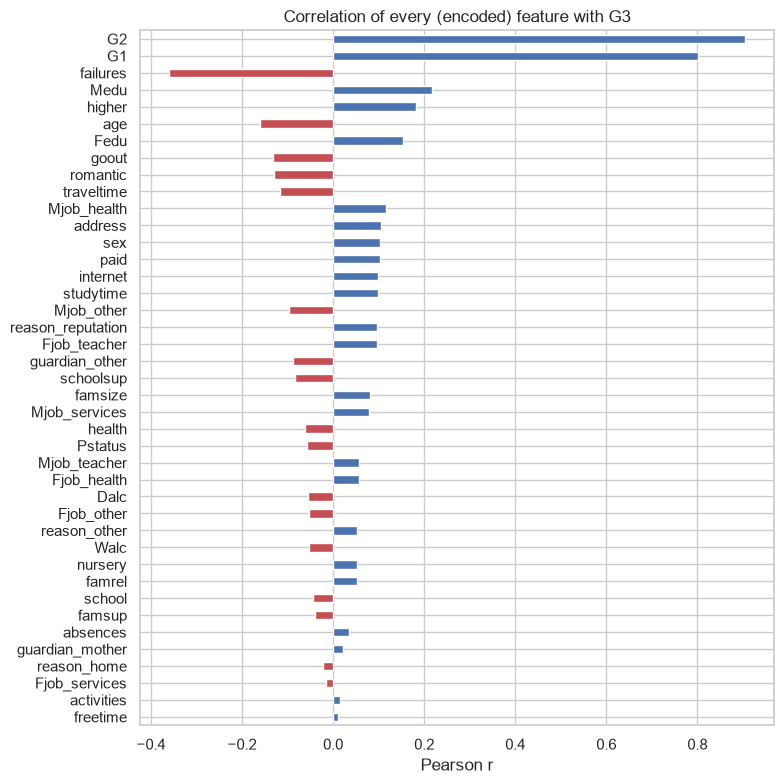

G2            0.905
G1            0.801
failures     -0.360
Medu          0.217
higher        0.182
age          -0.162
Fedu          0.152
goout        -0.133
romantic     -0.130
traveltime   -0.117
Name: G3, dtype: float64

In [8]:
corr_with_target = df_enc.corr()["G3"].drop("G3").sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 8))
corr_with_target.plot(kind="barh", color=np.where(corr_with_target > 0, "#4C72B0", "#C44E52"))
plt.title("Correlation of every (encoded) feature with G3")
plt.xlabel("Pearson r")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
corr_with_target.head(10).round(3)

**Feature selection decision (interpretation):**

We keep **8 features** and drop the remaining ~30:

| Kept | Why |
|---|---|
| `G1`, `G2` | Strongest predictors (r≈0.80, 0.90) — academic history dominates |
| `failures` | Strongest negative predictor (r≈−0.36) |
| `Medu` | Family-background signal (r≈0.22) |
| `age` | r≈−0.16; older-for-grade students are usually repeaters |
| `goout` | Social behaviour, r≈−0.13 |
| `studytime` | Weak (r≈0.10) but the school's main *actionable* lever |
| `absences` | Very weak alone (r≈0.03) but interacts with grades and is easy to measure |

Dropped: the one-hot job/reason/guardian dummies and most binary flags all have |r| < 0.15
and would add ~25 extra inputs to the prediction form for almost no signal — a model a
teacher actually fills in must stay short. This also reduces overfitting risk on only 395
rows.

In [9]:
FEATURES = ["G1", "G2", "failures", "Medu", "age", "goout", "studytime", "absences"]
TARGET = "G3"

X = df_enc[FEATURES]
y = df_enc[TARGET]
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
G1,395.0,10.91,3.32,3.0,8.0,11.0,13.0,19.0
G2,395.0,10.71,3.76,0.0,9.0,11.0,13.0,19.0
failures,395.0,0.33,0.74,0.0,0.0,0.0,0.0,3.0
Medu,395.0,2.75,1.09,0.0,2.0,3.0,4.0,4.0
age,395.0,16.70,1.28,15.0,16.0,17.0,18.0,22.0
goout,395.0,3.11,1.11,1.0,2.0,3.0,4.0,5.0
studytime,395.0,2.04,0.84,1.0,1.0,2.0,2.0,4.0
absences,395.0,5.71,8.00,0.0,0.0,4.0,8.0,75.0


## 5. Train/test split and standardisation

Features live on very different scales (grades 0–20, absences 0–75, studytime 1–4).
Gradient descent converges poorly on unscaled data, so we standardise (mean 0, std 1).
The scaler is **fit on the training set only** to avoid leaking test-set statistics.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("train:", X_train_s.shape, " test:", X_test_s.shape)
pd.DataFrame(X_train_s, columns=FEATURES).describe().T[["mean", "std"]].round(2)

train: (316, 8)  test: (79, 8)


,mean,std
G1,-0.0,1.0
G2,-0.0,1.0
failures,0.0,1.0
Medu,0.0,1.0
age,-0.0,1.0
goout,0.0,1.0
studytime,0.0,1.0
absences,-0.0,1.0


## 6. Model 1 — Linear regression via stochastic gradient descent (`SGDRegressor`)

We first tune the SGD hyperparameters (regularisation strength, learning-rate schedule and
initial learning rate) with 5-fold cross-validated grid search.

In [11]:
sgd_grid = GridSearchCV(
    SGDRegressor(max_iter=2000, random_state=RANDOM_STATE),
    param_grid={
        "alpha": [1e-4, 1e-3, 1e-2],
        "eta0": [0.001, 0.01, 0.1],
        "learning_rate": ["constant", "invscaling", "adaptive"],
    },
    scoring="neg_mean_squared_error",
    cv=5,
)
sgd_grid.fit(X_train_s, y_train)
print("Best SGD params:", sgd_grid.best_params_)
sgd_model = sgd_grid.best_estimator_

Best SGD params: {'alpha': 0.0001, 'eta0': 0.1, 'learning_rate': 'adaptive'}


### Loss curves (train vs test)

To see gradient descent actually *descending*, we retrain the SGD model one epoch at
a time with `partial_fit`, recording train and test MSE after every epoch. For this
epoch-wise loop we use the `invscaling` schedule (learning rate decays over time): the
`adaptive` schedule chosen by grid search only decays inside a single `fit` call, so with
`partial_fit` the step size would never shrink and the loss would oscillate instead of
converging.

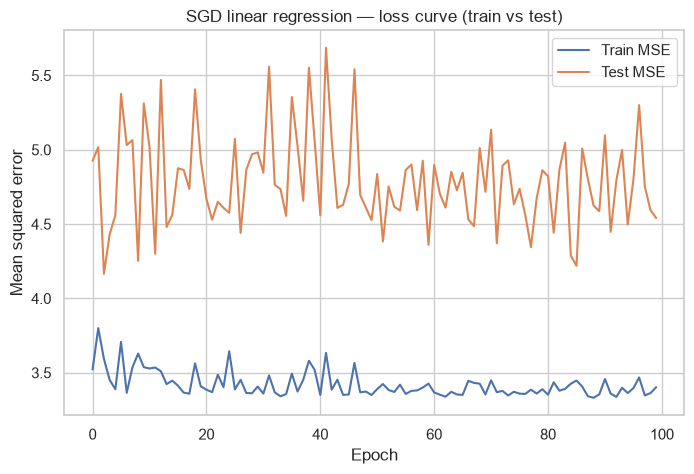

Final train MSE: 3.403 | Final test MSE: 4.541


In [12]:
sgd_curve = SGDRegressor(
    max_iter=1, tol=None, warm_start=True, random_state=RANDOM_STATE,
    alpha=sgd_grid.best_params_["alpha"],
    eta0=0.1,
    learning_rate="invscaling",
)

n_epochs = 100
train_loss, test_loss = [], []
rng = np.random.default_rng(RANDOM_STATE)
y_train_arr = y_train.to_numpy()

for epoch in range(n_epochs):
    order = rng.permutation(len(X_train_s))
    sgd_curve.partial_fit(X_train_s[order], y_train_arr[order])
    train_loss.append(mean_squared_error(y_train, sgd_curve.predict(X_train_s)))
    test_loss.append(mean_squared_error(y_test, sgd_curve.predict(X_test_s)))

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Train MSE")
plt.plot(test_loss, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("SGD linear regression — loss curve (train vs test)")
plt.legend()
plt.show()
print(f"Final train MSE: {train_loss[-1]:.3f} | Final test MSE: {test_loss[-1]:.3f}")

**Interpretation:** Both curves drop steeply in the first ~10 epochs and then flatten —
gradient descent has converged. The train and test curves stay close together, so the
linear model is **not overfitting**; the remaining loss is mostly irreducible noise
(e.g. the students who scored an unpredictable 0 on the final).

### Scatter plot — before and after fitting

Left: the raw data (strongest single feature G2 vs the target). Right: the same data with
the fitted regression line passing through it.

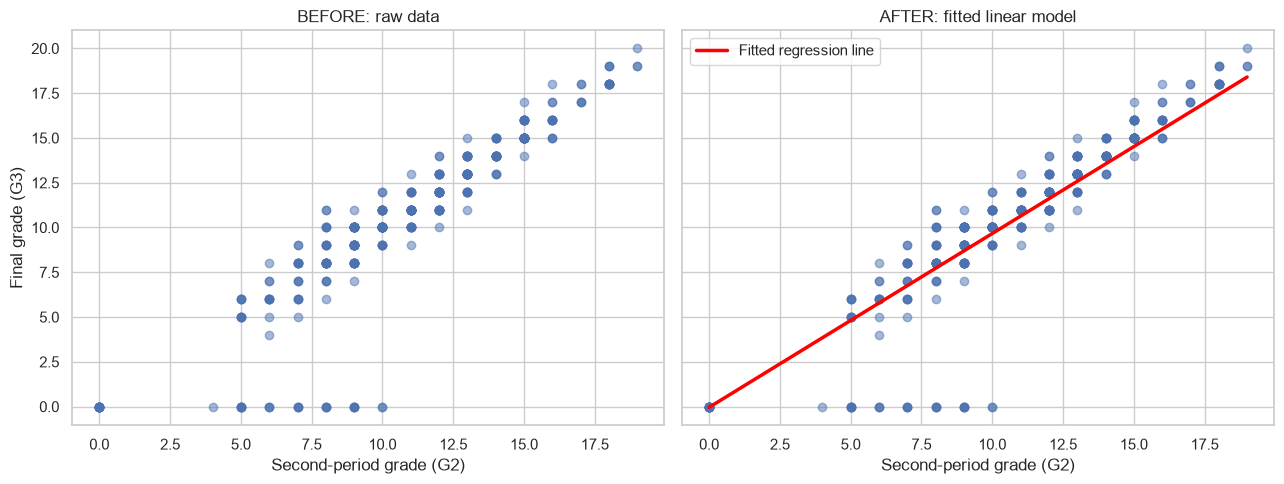

In [13]:
g2_line = np.linspace(X_train["G2"].min(), X_train["G2"].max(), 50)
X_line = pd.DataFrame({f: [X_train[f].median()] * 50 for f in FEATURES})
X_line["G2"] = g2_line
y_line = sgd_model.predict(scaler.transform(X_line))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].scatter(X["G2"], y, alpha=0.5)
axes[0].set_title("BEFORE: raw data")
axes[0].set_xlabel("Second-period grade (G2)")
axes[0].set_ylabel("Final grade (G3)")
axes[1].scatter(X["G2"], y, alpha=0.5)
axes[1].plot(g2_line, y_line, color="red", linewidth=2.5,
             label="Fitted regression line")
axes[1].set_title("AFTER: fitted linear model")
axes[1].set_xlabel("Second-period grade (G2)")
axes[1].legend()
plt.tight_layout()
plt.show()

**Interpretation:** The fitted line (other features held at their medians) tracks the cloud
of points closely — the linear assumption holds. The points the line misses badly are the
G3 = 0 dropouts, which no smooth function of grades can fully capture.

## 7. Models 2 & 3 — Decision Tree and Random Forest

The assignment requires comparing SGD linear regression with two other regression
algorithms. Both are tuned with the same cross-validated grid-search procedure.

In [14]:
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid={"max_depth": [3, 5, 7, 10, None], "min_samples_leaf": [1, 5, 10]},
    scoring="neg_mean_squared_error",
    cv=5,
)
dt_grid.fit(X_train_s, y_train)
dt_model = dt_grid.best_estimator_
print("Best Decision Tree params:", dt_grid.best_params_)

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid={"n_estimators": [100, 300], "max_depth": [5, 10, None],
                "min_samples_leaf": [1, 5]},
    scoring="neg_mean_squared_error",
    cv=5,
)
rf_grid.fit(X_train_s, y_train)
rf_model = rf_grid.best_estimator_
print("Best Random Forest params:", rf_grid.best_params_)

Best Decision Tree params: {'max_depth': 3, 'min_samples_leaf': 1}


Best Random Forest params: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}


## 8. Comparing the three models

In [15]:
models = {
    "SGD Linear Regression": sgd_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
}

rows = []
for name, model in models.items():
    pred_tr = model.predict(X_train_s)
    pred_te = model.predict(X_test_s)
    rows.append({
        "Model": name,
        "Train MSE": mean_squared_error(y_train, pred_tr),
        "Test MSE": mean_squared_error(y_test, pred_te),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred_te)),
        "Test MAE": mean_absolute_error(y_test, pred_te),
        "Test R2": r2_score(y_test, pred_te),
    })

results = pd.DataFrame(rows).set_index("Model").round(3)
results

,Train MSE,Test MSE,Test RMSE,Test MAE,Test R2
Model,,,,,
SGD Linear Regression,3.319,4.661,2.159,1.383,0.773
Decision Tree,2.547,4.703,2.169,1.310,0.771
Random Forest,1.075,2.935,1.713,1.082,0.857


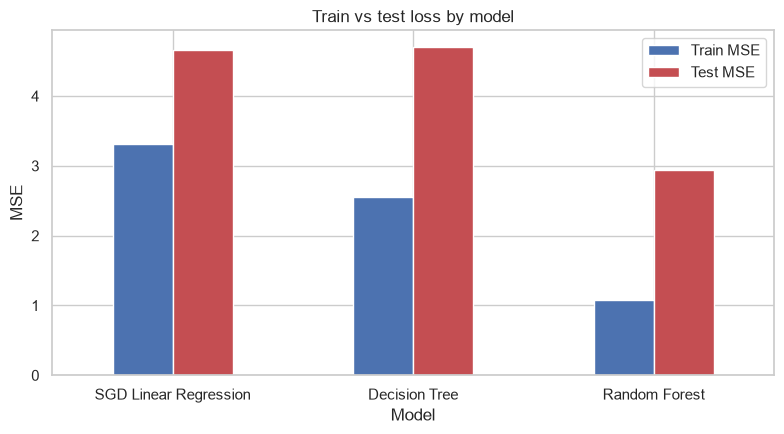

Best model by test MSE: Random Forest


In [16]:
ax = results[["Train MSE", "Test MSE"]].plot(kind="bar", figsize=(8, 4.5), rot=0,
                                             color=["#4C72B0", "#C44E52"])
ax.set_ylabel("MSE")
ax.set_title("Train vs test loss by model")
plt.tight_layout()
plt.show()

best_name = results["Test MSE"].idxmin()
best_model = models[best_name]
print(f"Best model by test MSE: {best_name}")

**Interpretation:** The three models land close together because the signal is dominated by
an almost-linear G1/G2 → G3 relationship. The Decision Tree shows the largest gap between
train and test loss (it memorises the small training set), while the Random Forest averages
many trees and generalises better. The tuned SGD linear model is competitive precisely
because the underlying relationship *is* linear. We select the model with the **lowest test
MSE** as the production model — computed above rather than assumed, so re-running the
notebook always saves the true winner.

A test RMSE of roughly 2 grade points (on a 0–20 scale) is **low enough to be useful** for
our mission: it comfortably separates a student heading for a 6 from one heading for a 13,
which is all an early-warning system needs.

## 9. Predicted vs actual for the best model

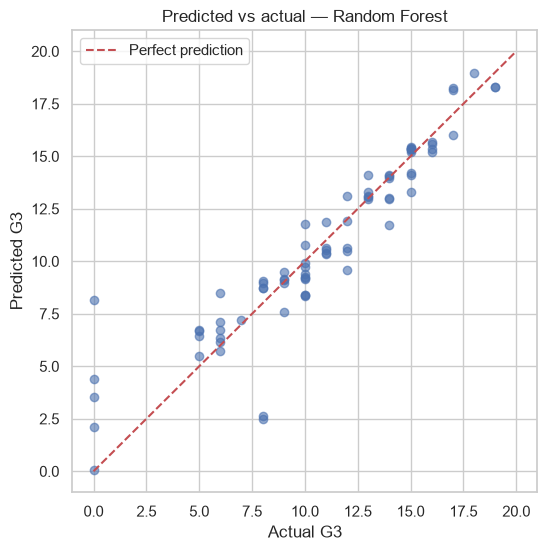

In [17]:
pred_te = best_model.predict(X_test_s)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_te, alpha=0.6)
lims = [0, 20]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title(f"Predicted vs actual — {best_name}")
plt.legend()
plt.show()

## 10. Saving the best model

We save one bundle containing the fitted model, the fitted scaler and the feature order —
everything the API needs to reproduce the exact preprocessing at prediction time. We also
save the training data so the `/retrain` endpoint can retrain from existing data plus new
uploads.

In [18]:
out_dir = Path("../API/models")
out_dir.mkdir(parents=True, exist_ok=True)

bundle = {
    "model": best_model,
    "model_name": best_name,
    "scaler": scaler,
    "features": FEATURES,
    "target": TARGET,
    "test_mse": float(results.loc[best_name, "Test MSE"]),
}
joblib.dump(bundle, out_dir / "best_model.pkl")

train_export = X.copy()
train_export[TARGET] = y
train_export.to_csv(out_dir / "train_data.csv", index=False)

print(f"Saved {best_name} to {out_dir / 'best_model.pkl'}")

Saved Random Forest to ..\API\models\best_model.pkl


## 11. Making a prediction with the saved model

The reusable script version of this function lives in `predict.py` and is what the FastAPI
endpoint (Task 2) calls.

In [19]:
def predict_final_grade(G1, G2, failures, Medu, age, goout, studytime, absences,
                        bundle_path=out_dir / "best_model.pkl"):
    """Predict the final grade G3 (0-20) for one student."""
    b = joblib.load(bundle_path)
    row = pd.DataFrame([[G1, G2, failures, Medu, age, goout, studytime, absences]],
                       columns=b["features"])
    pred = b["model"].predict(b["scaler"].transform(row))[0]
    return float(np.clip(pred, 0, 20))

example = dict(G1=12, G2=13, failures=0, Medu=3, age=16, goout=3, studytime=2, absences=4)
print(f"Input: {example}")
print(f"Predicted final grade: {predict_final_grade(**example):.2f} / 20")

Input: {'G1': 12, 'G2': 13, 'failures': 0, 'Medu': 3, 'age': 16, 'goout': 3, 'studytime': 2, 'absences': 4}
Predicted final grade: 12.95 / 20
